# Project 3: Analysing Political Images with a Vision Language Model

## Overview

In this project we use **GPT-4o**, a multimodal model that can process both text and images, to systematically code the content of political photographs. This extends the API skills from Project 2 to visual data.

**What is a vision language model?**  
Most language models process text only. Vision language models (VLMs) can additionally "see" images: they convert images into a rich internal representation that is fused with the text input before generating a response. GPT-4o, Claude, and Gemini all support image inputs. This means we can ask natural-language questions about an image — and receive structured answers.

**Why does this matter for social scientists?**  
Visual data is increasingly central to social science research: protest photographs, political advertisements, social media images, archival photographs, news images. Until recently, analysing images at scale required either expensive manual coding or specialised computer vision models that needed labelled training data. Vision LLMs offer a third path: describe your coding scheme in plain language and apply it to images immediately.

## Task: Coding Political Protest Images

We will analyse a set of publicly available photographs of political protests and events. For each image, we will ask GPT-4o to return a structured coding on several dimensions drawn from the visual content analysis literature:

| Field | Description |
|-------|-------------|
| `setting` | Where is the image taken? |
| `crowd_size` | Approximate scale of participation |
| `visible_signage` | Are protest signs or banners present? |
| `primary_theme` | The main political or social theme |
| `emotional_tone` | Overall emotional register of the image |
| `actors_visible` | Types of people or institutions visible |
| `image_type` | What kind of political image is this? |
| `confidence` | How confident is the model in its coding? |

## Learning objectives
1. Understand how multimodal LLMs process image + text inputs
2. Send images to the OpenAI vision API using both URLs and local files
3. Design a structured visual coding scheme and implement it as a prompt
4. Process multiple images and aggregate results into a dataset
5. Critically assess the limitations of automated image analysis


## Before You Start

This notebook uses the same OpenAI API key as Project 2. Make sure you have:
- An OpenAI account with API credit ([platform.openai.com](https://platform.openai.com))
- Your API key available as an environment variable or in Colab Secrets

> **Note on cost:** GPT-4o vision requests are priced based on image resolution. For standard images (≤1024px), each image costs approximately $0.001–$0.003. Processing 10 images costs roughly **$0.02–$0.05**.


## Setup: Install required libraries

In [1]:
pip install openai pandas matplotlib pillow requests

Note: you may need to restart the kernel to use updated packages.


## 1. Import Libraries and Connect to the API


In [2]:
import os
import json
import time
import base64
import requests
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from openai import OpenAI

# this needs to be defined in the .py file to lead to your API key, which should be stored in an environment variable for security
import define_API_key


# ── Set up the client (same as Project 2) ────────────────────────────────────
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# ── Option: Google Colab Secrets ─────────────────────────────────────────────
# from google.colab import userdata
# client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

print("OpenAI client ready.")


OpenAI client ready.


## 2. How Vision Language Models Work

When we send an image to the OpenAI API, the model processes it through a **vision encoder** — a neural network that converts the image into a sequence of numerical embeddings (similar to how text is tokenised). These image embeddings are concatenated with the text token embeddings and passed through the language model together.

The result is a model that can:
- Describe the content of images in natural language
- Answer factual questions about what is depicted
- Count people, read text in images, identify objects
- Reason about what is happening and why

Images can be sent to the API in two ways:
1. **As a URL** — the API fetches the image from the internet (must be publicly accessible)
2. **As base64-encoded bytes** — the image is embedded directly in the request (works for local files)

We demonstrate both methods below.


## 3. Our Image Dataset

We use a curated set of freely licensed photographs from Wikimedia Commons depicting political protests and social movements. These images span different issues (environment, gender rights, racial justice, Brexit) and geographies.

**Images are accessed via URL** — no download needed. The OpenAI API fetches them directly.

> **Using your own images:** Simply add entries to the `IMAGES` dictionary with a URL (for hosted images) or use the local file method shown later. For social media images, check licensing and terms of service before using images in research.


In [3]:
# A curated set of freely licensed political protest images from Wikimedia Commons
# Each entry: a short key, a public URL, and a human-readable label
#
# URLs are 960px thumbnails served via upload.wikimedia.org (verified 200 OK).
# Licences confirmed via the Wikimedia Commons imageinfo API.
IMAGES = {
    "womens_march_2017": {
        "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c9/Women%27s_March_on_Washington_%2832593123745%29.jpg/960px-Women%27s_March_on_Washington_%2832593123745%29.jpg",
        "label": "Women's March on Washington, January 2017",
        "source": "Wikimedia Commons (CC BY-SA 2.0)",
    },
    "extinction_rebellion_london_2019": {
        "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/8/8e/Extinction_Rebellion%2C_Oxford_Circus%2C_London%2C_April_19%2C_2019.jpg/960px-Extinction_Rebellion%2C_Oxford_Circus%2C_London%2C_April_19%2C_2019.jpg",
        "label": "Extinction Rebellion, Oxford Circus, London, April 2019",
        "source": "Wikimedia Commons (CC BY-SA 4.0)",
    },
    "fridays_for_future_berlin_2019": {
        "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/Front_of_the_3rd_Global_Climate_Strike_Berlin_FridaysForFuture_demonstration_78.jpg/960px-Front_of_the_3rd_Global_Climate_Strike_Berlin_FridaysForFuture_demonstration_78.jpg",
        "label": "Fridays for Future climate strike, Berlin, September 2019",
        "source": "Wikimedia Commons (CC0 / Public Domain)",
    },
    "peoples_vote_march_london_2019": {
        "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/%22Stop_Brexit%22_artwork_at_the_People%27s_Vote_March_in_London%2C_23rd_March_2019.jpg/960px-%22Stop_Brexit%22_artwork_at_the_People%27s_Vote_March_in_London%2C_23rd_March_2019.jpg",
        "label": "People's Vote (Anti-Brexit) March, London, March 2019",
        "source": "Wikimedia Commons (CC BY-SA 4.0)",
    },
    "blm_brooklyn_2020": {
        "url": "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg/960px-George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg",
        "label": "George Floyd / Black Lives Matter protest, Grand Army Plaza, Brooklyn, June 2020",
        "source": "Wikimedia Commons (CC BY 2.0)",
    },
}

print(f"Dataset: {len(IMAGES)} images")
for key, meta in IMAGES.items():
    print(f"  • {key}: {meta['label']}")

Dataset: 5 images
  • womens_march_2017: Women's March on Washington, January 2017
  • extinction_rebellion_london_2019: Extinction Rebellion, Oxford Circus, London, April 2019
  • fridays_for_future_berlin_2019: Fridays for Future climate strike, Berlin, September 2019
  • peoples_vote_march_london_2019: People's Vote (Anti-Brexit) March, London, March 2019
  • blm_brooklyn_2020: George Floyd / Black Lives Matter protest, Grand Army Plaza, Brooklyn, June 2020


### Viewing the images

Let's display all images so we can see what we will be analysing. This also serves as a sanity check that the URLs are accessible.


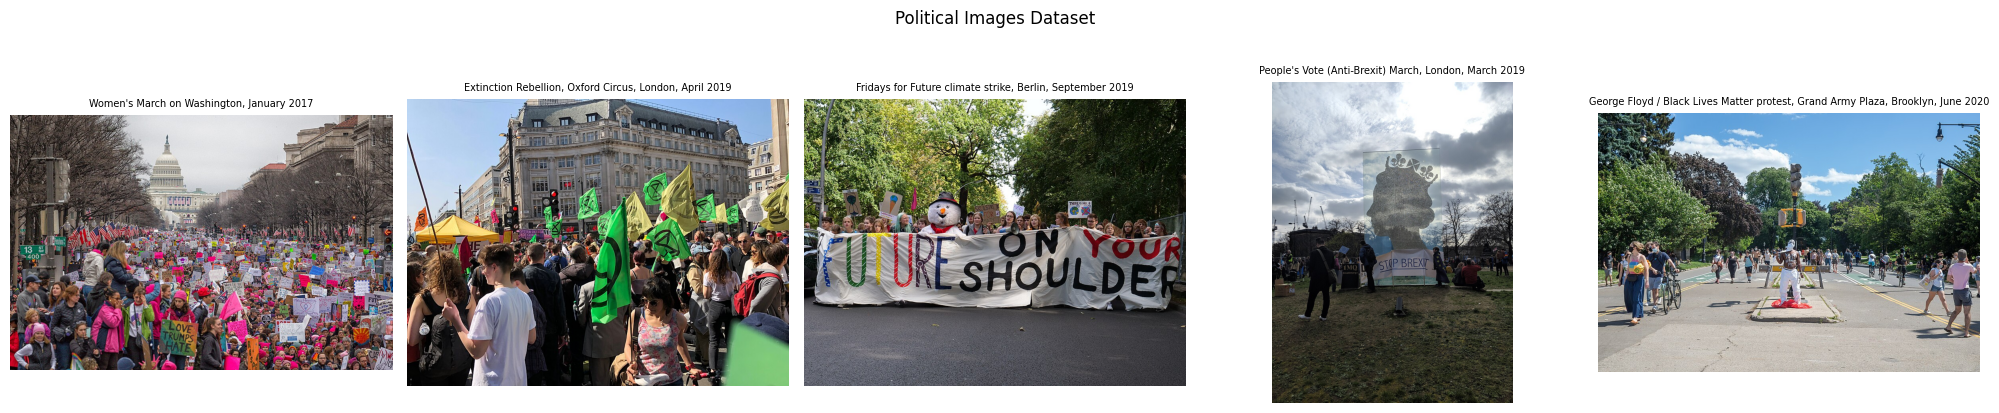

In [5]:
def load_image_from_url(url: str) -> Image.Image | None:
    """Download an image from a URL and return a PIL Image object."""
    headers = {"User-Agent": "Mozilla/5.0 (compatible; MY580-LLMs/1.0; educational use)"}
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"  Could not load image from {url}: {e}")
        return None

# Display all images in a grid
n = len(IMAGES)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

for ax, (key, meta) in zip(axes, IMAGES.items()):
    time.sleep(1)  # be polite to the server
    img = load_image_from_url(meta['url'])
    if img:
        ax.imshow(img)
        ax.set_title(meta['label'], fontsize=7, wrap=True)
    else:
        ax.text(0.5, 0.5, 'Could not load', ha='center', va='center')
        ax.set_title(key, fontsize=7)
    ax.axis('off')

plt.suptitle('Political Images Dataset', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# download the images and save them locally (optional)

# make a directory to save the images (if it doesn't exist)
if not os.path.exists("downloaded_images"):
    os.mkdir("downloaded_images")

# download and save each image
for key, meta in IMAGES.items():
    img = load_image_from_url(meta['url'])
    if img:
        filename = f"downloaded_images/{key}.jpg"
        img.save(filename)
        print(f"Saved {filename}")
        time.sleep(2)  # be polite to the server

Saved downloaded_images/womens_march_2017.jpg
Saved downloaded_images/extinction_rebellion_london_2019.jpg
Saved downloaded_images/fridays_for_future_berlin_2019.jpg
Saved downloaded_images/peoples_vote_march_london_2019.jpg
  Could not load image from https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg/960px-George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg: 429 Client Error: Too many requests (76af2b0) for url: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg/960px-George_Floyd_protest_in_Grand_Army_Plaza_June_7_%2872992%29.jpg


In [ ]:
# DEMO: load image from downloaded images
image1_test = Image.open("downloaded_images/womens_march_2017.jpg")
image1_test.show()

## 4. Sending an Image to the Model: Basic Description

Before applying a structured coding scheme, let's see what the model "sees" in a single image. We ask for a free-text description — a good first check that the model is interpreting the image correctly.

### How to structure a vision API request

The key difference from a text-only request is the message content format. Instead of a plain string, the `content` field becomes a list that can include both text and image objects:

```python
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text",      "text": "Describe this image."},
            {"type": "image_url", "image_url": {"url": "https://..."}},
        ]
    }
]
```


In [ ]:
def describe_image(image_url: str, prompt: str = "Describe this image in 2-3 sentences.") -> str:
    """Send an image URL to GPT-4o and return a text description."""
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text",      "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_url, "detail": "low"}},
                    # detail="low" uses fewer tokens (sufficient for most social science tasks)
                    # detail="high" tiles the image for finer analysis (use for dense text or maps)
                ],
            }
        ],
        max_tokens=300,
        temperature=0,
    )
    return response.choices[0].message.content

# Test on the first image from downloaded_images (or directly from the URL)
first_key = list(IMAGES.keys())[0]
first_image = IMAGES[first_key]

print(f"Image: {first_image['label']}")
print("-" * 60)
description = describe_image(first_image['url'])
print(description)


Image: Women's March on Washington, January 2017
------------------------------------------------------------
The image depicts a large crowd of people participating in a protest march in Washington, D.C., with the U.S. Capitol building visible in the background. Many participants are holding colorful signs with various messages, and some are wearing pink hats. The atmosphere appears energetic and peaceful, with a diverse group of individuals gathered for the event.


### Using local image files (optional)

If you have images saved locally (e.g., downloaded from a database, scraped from social media), you can send them as **base64-encoded bytes** instead of a URL. This works for any image — it does not need to be publicly accessible.

```python
def image_to_base64(file_path: str) -> str:
    with open(file_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# Then in the API call, use:
{
    "type": "image_url",
    "image_url": {
        "url": f"data:image/jpeg;base64,{image_to_base64('my_image.jpg')}"
    }
}
```

For this workshop we use URLs for simplicity, but the coding scheme and analysis are identical regardless of how the image is sent.


## 5. Designing a Structured Visual Coding Scheme

Systematic content analysis of images follows the same principles as text-based content analysis:

1. **Define dimensions**: what aspects of the image are theoretically relevant?
2. **Define categories**: for each dimension, what are the possible values?
3. **Write a codebook**: clear, unambiguous definitions so that coders (human or LLM) apply categories consistently
4. **Pilot and revise**: test the scheme on a sample; revise ambiguous categories

Our coding scheme is adapted from the visual framing literature (Koenig 2006; Rodriguez & Dimitrova 2011). We code eight dimensions that capture the political and social content of protest imagery.

**Tip for your own research:** Start with a small number of theoretically motivated dimensions rather than coding everything. More dimensions = more complexity = more opportunities for inconsistency.


In [7]:
# System prompt defining the coding scheme
# Good system prompts for structured tasks are:
#   (1) Specific about output format
#   (2) Clear about each field and its allowed values
#   (3) Explicit about edge cases

CODING_SYSTEM_PROMPT = """You are a social science research assistant trained in visual content analysis.

Your task is to systematically code political and social movement photographs according to a structured coding scheme.

Return ONLY a valid JSON object with exactly these fields and allowed values:

{
    "setting": "one of: outdoor_public_space, indoor_venue, parliament_or_government, street_march, other",

    "crowd_size": "one of: individual (1 person), small_group (2-20 people), medium_crowd (20-200 people), large_crowd (200+ people)",

    "visible_signage": "one of: yes, no, unclear",

    "primary_theme": "one of: environment_climate, racial_justice, gender_rights, electoral_politics, economic_rights, anti_war, immigration, civil_liberties, other",

    "emotional_tone": "one of: angry_confrontational, hopeful_celebratory, solemn_serious, determined_resolute, mixed, neutral_unclear",

    "actors_visible": "a list containing any of: protesters, police_security, politicians, media, bystanders, other — list all that apply",

    "image_type": "one of: march_procession, static_rally, direct_action, vigil_memorial, political_event, other",

    "confidence": "one of: high, medium, low — your overall confidence in the coding given image clarity and content"
}

Rules:
- Return only the JSON object, with no additional text or explanation
- For 'actors_visible', always return a list (even if it has only one item)
- If you are uncertain about a field, choose the closest match and set confidence to 'low' or 'medium'
- Base coding only on what is visually present — do not assume context from the image label
"""

print("Coding scheme defined.")
print("Fields:", ["setting", "crowd_size", "visible_signage", "primary_theme",
                  "emotional_tone", "actors_visible", "image_type", "confidence"])


Coding scheme defined.
Fields: ['setting', 'crowd_size', 'visible_signage', 'primary_theme', 'emotional_tone', 'actors_visible', 'image_type', 'confidence']


In [8]:
def code_image(image_url: str) -> dict | None:
    """
    Apply the structured coding scheme to an image.
    Returns a Python dictionary of coded values, or None if the call fails.
    """
    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": CODING_SYSTEM_PROMPT},
                {
                    "role": "user",
                    "content": [
                        {"type": "text",      "text": "Please code the following image according to the coding scheme."},
                        {"type": "image_url", "image_url": {"url": image_url, "detail": "low"}},
                    ],
                },
            ],
            max_tokens=300,
            temperature=0,            # deterministic: important for reproducibility
            response_format={"type": "json_object"},  # force valid JSON output
        )
        raw = response.choices[0].message.content
        return json.loads(raw)

    except (json.JSONDecodeError, Exception) as e:
        print(f"  Error: {e}")
        return None

# Test on a single image
test_key = "womens_march_2017"
test_meta = IMAGES[test_key]

print(f"Coding: {test_meta['label']}")
print("-" * 60)
result = code_image(test_meta['url'])

if result:
    for field, value in result.items():
        print(f"  {field:<22}: {value}")


Coding: Women's March on Washington, January 2017
------------------------------------------------------------
  setting               : street_march
  crowd_size            : large_crowd (200+ people)
  visible_signage       : yes
  primary_theme         : gender_rights
  emotional_tone        : hopeful_celebratory
  actors_visible        : ['protesters']
  image_type            : march_procession
  confidence            : high


## 6. Code All Images

Now we apply the coding scheme to every image in our dataset. The structure is the same as Project 2's extraction loop: iterate over rows, call the API, collect results.


In [16]:
all_codes = []

print(f"Coding {len(IMAGES)} images...")
print("=" * 60)

for key, meta in IMAGES.items():
    print(f"\nProcessing: {meta['label']}")
    codes = code_image(meta['url'])

    if codes:
        codes['image_key'] = key
        codes['image_label'] = meta['label']
        codes['image_url'] = meta['url']
        all_codes.append(codes)
        print(f"  ✓ Coded successfully (confidence: {codes.get('confidence', '?')})")
    else:
        print(f"  ✗ Failed")

    time.sleep(0.5)   # brief pause between requests

print(f"\nDone. {len(all_codes)} / {len(IMAGES)} images coded successfully.")


Coding 5 images...

Processing: Women's March on Washington, January 2017
  ✓ Coded successfully (confidence: high)

Processing: Extinction Rebellion, Oxford Circus, London, April 2019
  ✓ Coded successfully (confidence: high)

Processing: Fridays for Future climate strike, Berlin, September 2019
  ✓ Coded successfully (confidence: high)

Processing: People's Vote (Anti-Brexit) March, London, March 2019
  ✓ Coded successfully (confidence: high)

Processing: George Floyd / Black Lives Matter protest, Grand Army Plaza, Brooklyn, June 2020
  ✓ Coded successfully (confidence: medium)

Done. 5 / 5 images coded successfully.


In [17]:
# Build a clean DataFrame from the results
codes_df = pd.DataFrame(all_codes)

# Move identifier columns to the front
id_cols = ['image_key', 'image_label']
feature_cols = [c for c in codes_df.columns if c not in id_cols + ['image_url']]
codes_df = codes_df[id_cols + feature_cols]

print(f"Results shape: {codes_df.shape}")
codes_df


Results shape: (5, 10)


,image_key,image_label,setting,crowd_size,visible_signage,primary_theme,emotional_tone,actors_visible,image_type,confidence
0,womens_march_2017,"Women's March on Washington, January 2017",street_march,large_crowd (200+ people),yes,gender_rights,hopeful_celebratory,[protesters],march_procession,high
1,extinction_rebellion_london_2019,"Extinction Rebellion, Oxford Circus, London, A...",outdoor_public_space,large_crowd (200+ people),yes,environment_climate,determined_resolute,[protesters],static_rally,high
2,fridays_for_future_berlin_2019,"Fridays for Future climate strike, Berlin, Sep...",street_march,medium_crowd (20-200 people),yes,environment_climate,determined_resolute,[protesters],march_procession,high
3,peoples_vote_march_london_2019,"People's Vote (Anti-Brexit) March, London, Mar...",outdoor_public_space,medium_crowd (20-200 people),yes,electoral_politics,determined_resolute,[protesters],static_rally,high
4,blm_brooklyn_2020,"George Floyd / Black Lives Matter protest, Gra...",outdoor_public_space,medium_crowd,no,other,neutral_unclear,"[protesters, bystanders]",static_rally,medium


## 7. Analysing the Coded Results

With our images coded into a structured DataFrame, we can now perform the kind of quantitative analysis that is the end goal of systematic content analysis. Even with only five images, we can illustrate how the pipeline scales to larger corpora.


In [18]:
# Summary of each coded dimension
print("Summary of coded dimensions")
print("=" * 50)

for col in ['setting', 'crowd_size', 'primary_theme', 'emotional_tone', 'image_type', 'confidence']:
    if col in codes_df.columns:
        print(f"\n{col.upper()}:")
        print(codes_df[col].value_counts().to_string())


Summary of coded dimensions

SETTING:
setting
outdoor_public_space    3
street_march            2

CROWD_SIZE:
crowd_size
large_crowd (200+ people)       2
medium_crowd (20-200 people)    2
medium_crowd                    1

PRIMARY_THEME:
primary_theme
environment_climate    2
gender_rights          1
electoral_politics     1
other                  1

EMOTIONAL_TONE:
emotional_tone
determined_resolute    3
hopeful_celebratory    1
neutral_unclear        1

IMAGE_TYPE:
image_type
static_rally        3
march_procession    2

CONFIDENCE:
confidence
high      4
medium    1


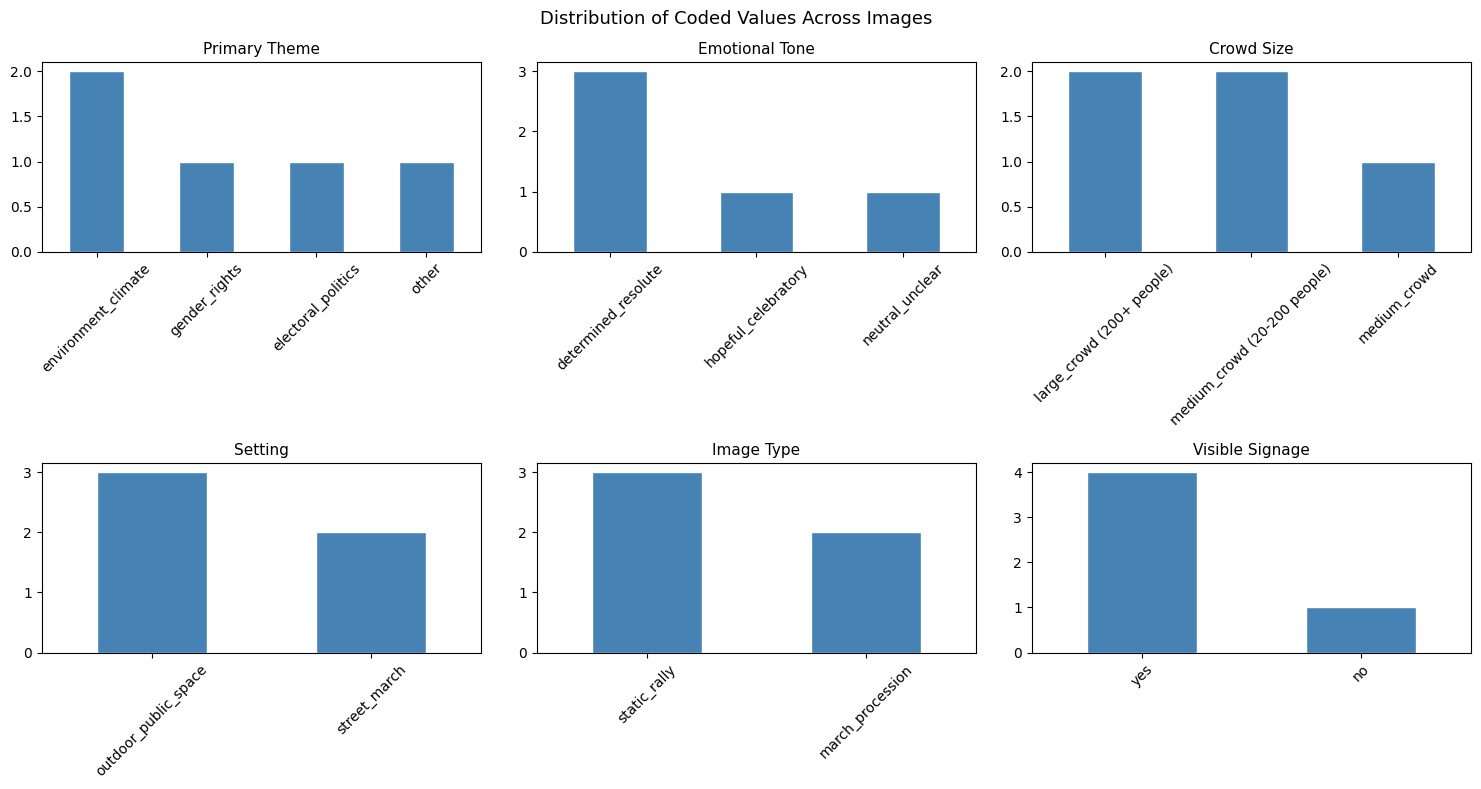

In [19]:
# Visual summary: key coded dimensions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_cols = ['primary_theme', 'emotional_tone', 'crowd_size', 'setting', 'image_type', 'visible_signage']

for ax, col in zip(axes.flatten(), plot_cols):
    if col in codes_df.columns:
        codes_df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col.replace('_', ' ').title(), fontsize=11)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Coded Values Across Images', fontsize=13)
plt.tight_layout()
plt.show()


In [20]:
# View the actors_visible field — this was returned as a list, so we need to handle it differently
# Convert lists to strings for display
codes_df['actors_str'] = codes_df['actors_visible'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)

print("Actors visible in each image:")
print("-" * 60)
for _, row in codes_df.iterrows():
    print(f"  {row['image_label'][:50]:<50} | {row['actors_str']}")


Actors visible in each image:
------------------------------------------------------------
  Women's March on Washington, January 2017          | protesters
  Extinction Rebellion, Oxford Circus, London, April | protesters
  Fridays for Future climate strike, Berlin, Septemb | protesters
  People's Vote (Anti-Brexit) March, London, March 2 | protesters
  George Floyd / Black Lives Matter protest, Grand A | protesters, bystanders


## 8. Assessing Reliability: Running the Model Twice

A key question for research use is: **how consistent are the model's codings?** Unlike human coders, we can run the same model on the same image multiple times and compare outputs. This gives us a sense of the model's internal consistency.

We expect some variation because language models are probabilistic — even at `temperature=0`, very long outputs can differ slightly. The fields most likely to vary are complex judgment calls like `emotional_tone`; simpler observable features like `visible_signage` should be highly consistent.


In [21]:
# Re-code two images to check consistency
print("Consistency check: re-coding two images")
print("=" * 60)

for key in list(IMAGES.keys())[:2]:
    meta = IMAGES[key]
    print(f"\nImage: {meta['label']}")

    # Original coding (already stored in codes_df)
    original = codes_df[codes_df['image_key'] == key].iloc[0]

    # Second run
    second = code_image(meta['url'])
    time.sleep(0.5)

    if second:
        print(f"{'Field':<22} {'Run 1':<25} {'Run 2':<25} {'Match'}")
        print("-" * 80)
        for field in ['setting', 'crowd_size', 'primary_theme', 'emotional_tone', 'image_type', 'visible_signage']:
            if field in original.index and field in second:
                v1 = str(original[field])
                v2 = str(second[field])
                match = "✓" if v1 == v2 else "✗"
                print(f"  {field:<20} {v1:<25} {v2:<25} {match}")


Consistency check: re-coding two images

Image: Women's March on Washington, January 2017
Field                  Run 1                     Run 2                     Match
--------------------------------------------------------------------------------
  setting              street_march              street_march              ✓
  crowd_size           large_crowd (200+ people) large_crowd (200+ people) ✓
  primary_theme        gender_rights             gender_rights             ✓
  emotional_tone       hopeful_celebratory       hopeful_celebratory       ✓
  image_type           march_procession          march_procession          ✓
  visible_signage      yes                       yes                       ✓

Image: Extinction Rebellion, Oxford Circus, London, April 2019
Field                  Run 1                     Run 2                     Match
--------------------------------------------------------------------------------
  setting              outdoor_public_space      outdoor_pub

## 9. Limitations and Ethical Considerations

### Technical limitations

**Hallucination and confabulation**  
Vision models can confidently describe things that are not in the image, especially when prompted to infer context. Always validate a sample of codings manually, particularly for high-stakes research.

**Image resolution and quality**  
Low-resolution images, poor lighting, crowds, or partial occlusion reduce accuracy. The `confidence` field in our scheme helps flag uncertain cases.

**Cultural and representational bias**  
These models are trained predominantly on Western, English-language data. They may perform less well on protests from outside North America and Europe, and may apply culturally specific interpretive frames.

**Temporal limitations**  
The model was trained up to a knowledge cutoff date. Events after this date may not be recognisable in their political context (though coding observable visual features does not require recognising specific events).

### Ethical considerations

**Consent and privacy**  
Many protest photographs depict identifiable individuals who did not consent to being subjects of research. Be aware of IRB/ethics requirements for your institution and jurisdiction. De-identification or working with aggregated descriptions may be appropriate.

**Misuse potential**  
Automated image analysis of protest imagery could be used by governments or law enforcement for surveillance. Consider the dual-use potential of your methods and data when publishing.

**Transparency and reproducibility**  
Always report the model version, prompt text, temperature setting, and date of analysis. Results may differ as models are updated. Archiving the raw API outputs alongside your coded data enables replication.

### Comparison to human coders

| Criterion | Human coders | Vision LLM |
|-----------|-------------|------------|
| Initial cost | High (training, time) | Low (prompt design) |
| Per-image cost | Medium–high | Very low |
| Consistency | Can be trained to be high | Medium–high, varies by field |
| Transparency | Codebook-based | Prompt-based (less interpretable) |
| Cultural sensitivity | Can be matched to image context | Biased toward training data |
| IRB / ethics | Well-understood | Evolving norms |

The right tool depends on your research context. For exploratory work or large-scale corpora, LLM coding is increasingly viable. For high-stakes or novel cultural contexts, human coding remains the gold standard.


In [22]:
# Save coded results to CSV for further analysis or reporting
# actors_visible is a list, so convert to string for CSV storage
export_df = codes_df.copy()
export_df['actors_visible'] = export_df['actors_visible'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else str(x)
)

output_path = '../data/image_codes.csv'
export_df.drop(columns=['image_url'], errors='ignore').to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")
export_df.drop(columns=['image_url', 'actors_str'], errors='ignore')


Results saved to: ../data/image_codes.csv


,image_key,image_label,setting,crowd_size,visible_signage,primary_theme,emotional_tone,actors_visible,image_type,confidence
0,womens_march_2017,"Women's March on Washington, January 2017",street_march,large_crowd (200+ people),yes,gender_rights,hopeful_celebratory,protesters,march_procession,high
1,extinction_rebellion_london_2019,"Extinction Rebellion, Oxford Circus, London, A...",outdoor_public_space,large_crowd (200+ people),yes,environment_climate,determined_resolute,protesters,static_rally,high
2,fridays_for_future_berlin_2019,"Fridays for Future climate strike, Berlin, Sep...",street_march,medium_crowd (20-200 people),yes,environment_climate,determined_resolute,protesters,march_procession,high
3,peoples_vote_march_london_2019,"People's Vote (Anti-Brexit) March, London, Mar...",outdoor_public_space,medium_crowd (20-200 people),yes,electoral_politics,determined_resolute,protesters,static_rally,high
4,blm_brooklyn_2020,"George Floyd / Black Lives Matter protest, Gra...",outdoor_public_space,medium_crowd,no,other,neutral_unclear,"protesters, bystanders",static_rally,medium


## 10. Extensions and Further Ideas

### Scaling up
The same pipeline works for hundreds or thousands of images. For large-scale studies:
- Use **asynchronous API calls** to process images in parallel (much faster)
- Store results incrementally to a database or CSV in case of interruptions
- Use `gpt-4o-mini` instead of `gpt-4o` for lower cost, then validate against a smaller `gpt-4o` sample

### Richer coding schemes
You can extend the scheme to code:
- **Text visible in signs** (OCR is automatic with vision models)
- **Symbolic objects** (flags, banners, colours — useful for political symbolism research)
- **Police tactics** (riot gear, lines, dispersal strategies)
- **Spatial composition** (foreground focus, background, camera angle)

### Multimodal research designs
- Combine image coding with text analysis of captions or news articles (Projects 2 + 3 together)
- Use vision models to verify descriptions produced by human coders
- Compare how the same protest event is photographed by different news outlets

### Alternative models
- **Claude** (Anthropic) and **Gemini** (Google) also support vision inputs and may perform differently on specific image types
- **CLIP** (OpenAI, open-source) provides zero-shot image classification without API costs — useful for simpler binary classification tasks
- **Florence-2** and **LLaVA** are open-source vision-language models that can run locally
